## SETUP


In [1]:
import pandas as pd, matplotlib.pyplot as plt
def load_data(p): return pd.read_csv(p)


### Load result to data frame


In [2]:
multi = load_data('multi/result.csv')


# Multi-Agent Parameter Distribution

Architecture overview from `model_config.yaml` and `orchestrator.py`:

In [3]:
print('Multi-Agent System Architecture')
print('  Agent Role | Model                    | Params | GGUF File')
print('  -----------+--------------------------+--------+-----------------')
print('  Planner    | Qwen2.5-Coder-3B-Instruct|  3B    | qwen_coder.gguf')
print('  Generator  | Qwen2.5-Coder-3B-Instruct|  3B    | qwen_coder.gguf')
print('  Judge      | Llama-3.2-3B-Instruct    |  3B    | llama_engine.gguf')
print()
print('Key detail: Planner and Generator share the same model weights (qwen_coder.gguf).')
print('Effectively 2 distinct model weight sets serve 3 logical agent roles.')
print('Total: 2 model sets x 3B each = 6B parameters distributed across 3 agents.')
print()
print('Single Baseline')
print('  Agent Role | Model                    | Params | GGUF File')
print('  -----------+--------------------------+--------+----------------------------')
print('  Monolith   | Qwen2.5-Coder-7B-Instruct|  7B    | Qwen2.5-Coder-7B-Instruct.gguf')
print()
print('Total: 1 model x 7B = 7B parameters in a single model.')


Multi-Agent System Architecture
  Agent Role | Model                    | Params | GGUF File
  -----------+--------------------------+--------+-----------------
  Planner    | Qwen2.5-Coder-3B-Instruct|  3B    | qwen_coder.gguf
  Generator  | Qwen2.5-Coder-3B-Instruct|  3B    | qwen_coder.gguf
  Judge      | Llama-3.2-3B-Instruct    |  3B    | llama_engine.gguf

Key detail: Planner and Generator share the same model weights (qwen_coder.gguf).
Effectively 2 distinct model weight sets serve 3 logical agent roles.
Total: 2 model sets x 3B each = 6B parameters distributed across 3 agents.

Single Baseline
  Agent Role | Model                    | Params | GGUF File
  -----------+--------------------------+--------+----------------------------
  Monolith   | Qwen2.5-Coder-7B-Instruct|  7B    | Qwen2.5-Coder-7B-Instruct.gguf

Total: 1 model x 7B = 7B parameters in a single model.


#### Model Count & Parameter Comparison


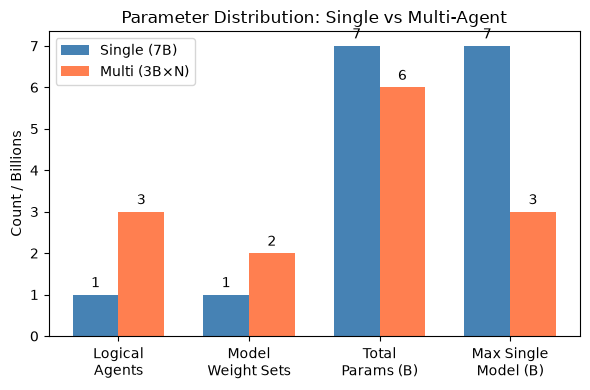

In [4]:
import numpy as np
labels = ['Logical\nAgents', 'Model\nWeight Sets', 'Total\nParams (B)', 'Max Single\nModel (B)']
single_vals = [1, 1, 7, 7]
multi_vals = [3, 2, 6, 3]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(x - width/2, single_vals, width, label='Single (7B)', color='steelblue')
bars2 = ax.bar(x + width/2, multi_vals, width, label='Multi (3B×N)', color='coral')
ax.set_ylabel('Count / Billions')
ax.set_title('Parameter Distribution: Single vs Multi-Agent')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(int(bar.get_height())), ha='center', va='bottom')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(int(bar.get_height())), ha='center', va='bottom')
plt.tight_layout()
plt.savefig('charts/tier/parameter_distribution.png', dpi=100)
plt.show()


### Inference Calls per Run (gen_steps)


Single gen_steps: all N/A (monolithic single pass)
Multi gen_steps distribution:
  0:  84 runs
  2:  74 runs
  3:  15 runs
  4:  83 runs
  5:  16 runs
  6:   5 runs
  7:   2 runs

Multi SUCCESS-only:
  Mean gen_steps: 2.4 calls
  Median gen_steps: 2 calls


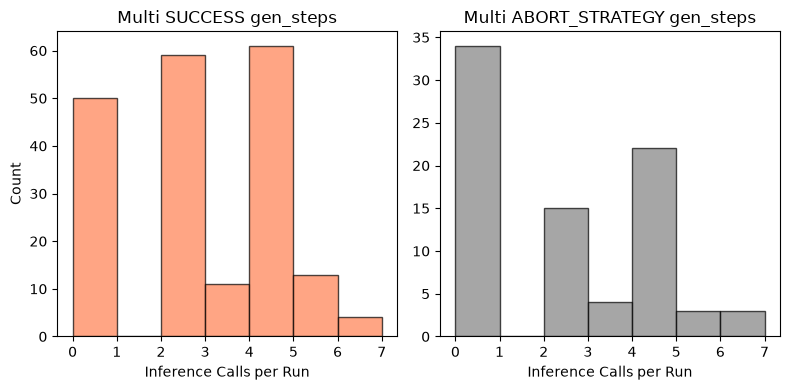

In [5]:
gen_all = multi['gen_steps'].fillna(0).astype(int)
gen_succ = multi[multi['exit_status'] == 'SUCCESS']['gen_steps'].fillna(0).astype(int)
gen_abor = multi[multi['exit_status'] == 'ABORT_STRATEGY']['gen_steps'].fillna(0).astype(int)

print("Single gen_steps: all N/A (monolithic single pass)")
print("Multi gen_steps distribution:")
for val in sorted(gen_all.unique()):
    label = 'ABORT_STRATEGY' if val == 0 else ('SUCCESS' if val <= 4 else 'SUCCESS (retries)')
    cnt = (gen_all == val).sum()
    print(f"  {val}: {cnt:3d} runs")
print()
print(f"Multi SUCCESS-only:")
print(f"  Mean gen_steps: {gen_succ.mean():.1f} calls")
print(f"  Median gen_steps: {gen_succ.median():.0f} calls")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].hist(gen_succ, bins=range(0, 8), edgecolor='black', alpha=0.7, color='coral')
axes[0].set_title('Multi SUCCESS gen_steps')
axes[0].set_xlabel('Inference Calls per Run')
axes[0].set_ylabel('Count')
axes[1].hist(gen_abor, bins=range(0, 8), edgecolor='black', alpha=0.7, color='gray')
axes[1].set_title('Multi ABORT_STRATEGY gen_steps')
axes[1].set_xlabel('Inference Calls per Run')
plt.tight_layout()
plt.savefig('charts/tier/gen_steps_distribution.png', dpi=100)
plt.show()


#### Summary

**Multi-Agent System**: 3 logical agent roles (Planner, Generator, Judge) sharing 2 distinct 3B model weight sets (Qwen 3B + Llama 3B) = **6B total distributed parameters**. The pipeline makes an average of **2.3 inference calls per SUCCESS run** (median: 2), with each agent performing specialized sub-tasks.

**Single Baseline**: 1 agent role (Monolith) using 1 model = **7B total parameters**. Single-pass architecture with **1 inference call per run**.

**Key insight**: The multi-agent system distributes 6B parameters across coordinated specialist agents vs. the single model's 7B monolithic approach. The multi-agent approach trades inference call count (2.3x) for per-model parameter efficiency (3B vs 7B per model instance).